# Deep EDA — Datasets & Preprocessing

Extends `eda_aptos.ipynb`. Answers the four mentor-flagged gaps with
statistical rigor:

* **A. Dataset-level additions** — covariate shift (MMD), near-duplicates (pHash),
  resolution/aspect per class, illumination clustering, quality×class crosstab,
  patient-leakage disclaimer.
* **B. Preprocessing ablation** — linear-probe QWK across preprocessing variants
  (raw, CLAHE, Ben-Graham σ-sweep, crop style), augmentation sanity check,
  class-separability preservation, color-space probe.
* **C. Cross-dataset audit** — APTOS vs EyePACS vs IDRiD statistical summary,
  EyePACS label-noise estimate.

Heavy-compute cells (MMD, linear probes) cache to `../results/eda_cache/`.
Re-runs are cheap after the first pass.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import (
    CLASS_NAMES, IMAGE_SIZE, TRAIN_CSV, TEST_CSV,
    TRAIN_IMG_DIR, TEST_IMG_DIR,
    IDRID_CSV, IDRID_PROCESSED_DIR,
)
from src.dataset import ben_graham_preprocess, load_labels
from src.analysis import fundus_cv, quality_metrics, eda_utils


def _resolve(p: Path, fallback: Path) -> Path:
    return p if p.exists() else fallback


# Fallback: some installs store data directly under data/ rather than data/data_split/
TRAIN_CSV = _resolve(TRAIN_CSV, ROOT / 'data' / 'train_label.csv')
TEST_CSV = _resolve(TEST_CSV, ROOT / 'data' / 'test_label.csv')
TRAIN_IMG_DIR = _resolve(TRAIN_IMG_DIR, ROOT / 'data' / 'train_split')
TEST_IMG_DIR = _resolve(TEST_IMG_DIR, ROOT / 'data' / 'test_split')

CACHE_DIR = ROOT / 'results' / 'eda_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
SEED = 42
rng = np.random.default_rng(SEED)

train_labels = load_labels(TRAIN_CSV)
test_labels = load_labels(TEST_CSV)
print(f'APTOS train: {len(train_labels):>5} images')
print(f'APTOS test : {len(test_labels):>5} images')
print(f'Classes     : {CLASS_NAMES}')


APTOS train:  3112 images
APTOS test :   550 images
Classes     : ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']


In [2]:
def load_rgb(code: str, img_dir: Path) -> np.ndarray | None:
    p = img_dir / f'{code}.png'
    if not p.exists():
        return None
    img = cv2.imread(str(p))
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def stratified_sample(labels: dict[str, int], n_per_class: int, rng) -> list[str]:
    by_class: dict[int, list[str]] = {}
    for code, lbl in labels.items():
        by_class.setdefault(lbl, []).append(code)
    out: list[str] = []
    for lbl, codes in by_class.items():
        k = min(n_per_class, len(codes))
        out.extend(rng.choice(codes, size=k, replace=False).tolist())
    return out


---

## Section A — Dataset-level additions

Goes beyond the basic class-count and channel-statistics found in
`eda_aptos.ipynb`. Each subsection answers a specific thesis question.


### A1. Covariate shift — MMD on ImageNet features

**Question:** is the test set drawn from the same distribution as the train set,
or is there feature-level drift beyond what the chi² label test catches?

Method: extract 2048-dim ResNet-50 (ImageNet-pretrained) features; compute
MMD² between a train subsample and the full test set; compare against a null
obtained by random train-vs-train splits.


In [3]:
# --- A1: Covariate-shift MMD test (GPU recommended) ---
import torch

FEAT_CACHE = CACHE_DIR / 'aptos_features.npz'
N_TRAIN_SUB = 800  # keep MMD matrix tractable

if FEAT_CACHE.exists():
    d = np.load(FEAT_CACHE)
    feats_train, feats_test = d['train'], d['test']
    codes_train = d['train_codes'].tolist()
    codes_test = d['test_codes'].tolist()
    print(f'Loaded cached features: train {feats_train.shape}, test {feats_test.shape}')
else:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model, preproc = eda_utils.load_imagenet_resnet50(device=device)

    train_codes = list(train_labels.keys())
    test_codes = list(test_labels.keys())
    sub_train = rng.choice(train_codes, size=min(N_TRAIN_SUB, len(train_codes)),
                           replace=False).tolist()

    def gen(codes, img_dir):
        for c in tqdm(codes, desc=f'load {img_dir.name}'):
            img = load_rgb(c, img_dir)
            if img is not None:
                yield img

    feats_train = eda_utils.extract_features(gen(sub_train, TRAIN_IMG_DIR),
                                              model, preproc, device=device)
    feats_test = eda_utils.extract_features(gen(test_codes, TEST_IMG_DIR),
                                             model, preproc, device=device)
    np.savez(FEAT_CACHE, train=feats_train, test=feats_test,
             train_codes=np.array(sub_train), test_codes=np.array(test_codes))
    codes_train, codes_test = sub_train, test_codes
    print(f'Saved features: train {feats_train.shape}, test {feats_test.shape}')


load train_split:   0%|          | 0/800 [00:00<?, ?it/s]

load test_split:   0%|          | 0/550 [00:00<?, ?it/s]

Saved features: train (800, 2048), test (550, 2048)


In [4]:
# Observed MMD: train-sub vs test
obs_mmd, p_val = eda_utils.mmd_permutation_test(
    feats_train, feats_test, n_permutations=200, rng=rng,
)
print(f'MMD²(train,test) = {obs_mmd:.5f}   permutation-p = {p_val:.4f}')

# Null distribution: MMD between two random halves of train (should be ~0)
n_half = len(feats_train) // 2
nulls = []
for _ in range(20):
    perm = rng.permutation(len(feats_train))
    nulls.append(eda_utils.mmd_rbf(feats_train[perm[:n_half]],
                                    feats_train[perm[n_half:2*n_half]]))
print(f'Null (train-vs-train) MMD² mean={np.mean(nulls):.5f}  '
      f'95% upper={np.quantile(nulls, 0.95):.5f}')


MMD²(train,test) = 0.00193   permutation-p = 0.4328
Null (train-vs-train) MMD² mean=0.00310  95% upper=0.00443


### A2. Near-duplicate detection — perceptual hash

**Question:** are there near-duplicate images *within* train, *within* test, or
*across* the train/test boundary (leakage)?

Method: 16×16 DCT pHash, report pairs with Hamming distance ≤ 5.


In [5]:
# --- A2: Near-duplicate via pHash ---
HASH_CACHE = CACHE_DIR / 'aptos_phash.npz'

def build_hashes(codes, img_dir, desc):
    out: dict[str, np.ndarray] = {}
    for c in tqdm(codes, desc=desc):
        img = load_rgb(c, img_dir)
        if img is not None:
            out[c] = eda_utils.phash(img, hash_size=16)
    return out

if HASH_CACHE.exists():
    d = np.load(HASH_CACHE, allow_pickle=True)
    hashes_train = dict(zip(d['train_codes'], d['train_hashes']))
    hashes_test = dict(zip(d['test_codes'], d['test_hashes']))
else:
    hashes_train = build_hashes(list(train_labels.keys()), TRAIN_IMG_DIR, 'phash train')
    hashes_test = build_hashes(list(test_labels.keys()), TEST_IMG_DIR, 'phash test')
    np.savez(
        HASH_CACHE,
        train_codes=np.array(list(hashes_train.keys())),
        train_hashes=np.stack(list(hashes_train.values())),
        test_codes=np.array(list(hashes_test.keys())),
        test_hashes=np.stack(list(hashes_test.values())),
    )
print(f'Hashed: train {len(hashes_train)}  test {len(hashes_test)}')


phash train:   0%|          | 0/3112 [00:00<?, ?it/s]

phash test:   0%|          | 0/550 [00:00<?, ?it/s]

Hashed: train 3112  test 550


In [6]:
# Within-train duplicates
within_train = eda_utils.find_near_duplicates(hashes_train, threshold=5)
within_test = eda_utils.find_near_duplicates(hashes_test, threshold=5)
print(f'Near-duplicate pairs in train: {len(within_train)}')
print(f'Near-duplicate pairs in test : {len(within_test)}')

# Cross-split (leakage): for each test image, find closest train hash
train_codes = list(hashes_train.keys())
train_mat = np.stack([hashes_train[c] for c in train_codes])
leakage = []
for tc, th in tqdm(hashes_test.items(), desc='cross-split scan'):
    d = np.sum(train_mat != th, axis=1)
    j = int(d.argmin())
    if d[j] <= 5:
        leakage.append((tc, train_codes[j], int(d[j])))
print(f'Cross-split near-duplicates (test<->train, d≤5): {len(leakage)}')
if leakage:
    display(pd.DataFrame(leakage, columns=['test_code', 'train_code', 'hamming']).head(20))


Near-duplicate pairs in train: 105
Near-duplicate pairs in test : 3


cross-split scan:   0%|          | 0/550 [00:00<?, ?it/s]

Cross-split near-duplicates (test<->train, d≤5): 38


,test_code,train_code,hamming
0,38487e1a5b1f,b376def52ccc,0
1,bb7e0a2544cd,e76a9cbb2a8c,0
2,a8b637abd96b,e2c3b037413b,0
3,3435fd8675a2,c62585bd68fb,0
4,05a5183c92d0,63a03880939c,0
5,75a7bc945b7d,98104c8c67eb,0
6,f066db7a2efe,278aa860dffd,0
7,6cb98da77e3e,48c49f662f7d,0
8,8446826853d0,8ef2eb8c51c4,0
9,77a9538b8362,40e9b5630438,0


### A3. Resolution & aspect-ratio heterogeneity per class

**Question:** does image resolution correlate with class? If yes, the model may
be picking up a *resolution* signal rather than a *pathology* signal.


In [7]:
# --- A3: Native resolution + aspect ratio per class ---
SIZE_CACHE = CACHE_DIR / 'aptos_sizes.csv'

if SIZE_CACHE.exists():
    sizes_df = pd.read_csv(SIZE_CACHE)
else:
    rows = []
    for split_name, labels, img_dir in [
        ('train', train_labels, TRAIN_IMG_DIR),
        ('test', test_labels, TEST_IMG_DIR),
    ]:
        for code, lbl in tqdm(labels.items(), desc=split_name):
            p = img_dir / f'{code}.png'
            if not p.exists():
                continue
            img = cv2.imread(str(p))
            if img is None:
                continue
            h, w = img.shape[:2]
            rows.append({'split': split_name, 'id': code, 'label': lbl,
                         'height': h, 'width': w, 'aspect': w / h})
    sizes_df = pd.DataFrame(rows)
    sizes_df.to_csv(SIZE_CACHE, index=False)

print(sizes_df.groupby(['split', 'label']).agg(
    n=('id', 'count'),
    h_mean=('height', 'mean'), h_std=('height', 'std'),
    w_mean=('width', 'mean'), w_std=('width', 'std'),
    aspect_mean=('aspect', 'mean'),
).round(1))


train:   0%|          | 0/3112 [00:00<?, ?it/s]

test:   0%|          | 0/550 [00:00<?, ?it/s]

                n  h_mean  h_std  w_mean  w_std  aspect_mean
split label                                                 
test  0       271  1201.5  401.9  1429.6  623.1          1.2
      1        56  1679.5  434.2  2305.4  693.5          1.4
      2       150  1893.8  435.0  2686.0  644.2          1.4
      3        29  1870.6  378.0  2621.1  563.3          1.4
      4        44  1915.6  586.6  2748.5  917.6          1.4
train 0      1534  1207.6  408.2  1434.1  630.7          1.2
      1       314  1803.4  385.6  2501.1  609.4          1.4
      2       849  1838.1  502.5  2589.4  749.6          1.4
      3       164  1835.6  403.4  2585.4  611.6          1.4
      4       251  1867.3  517.0  2612.0  766.9          1.4


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33840\1860602565.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(CLASS_NAMES, rotation=30)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33840\1860602565.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(CLASS_NAMES, rotation=30)


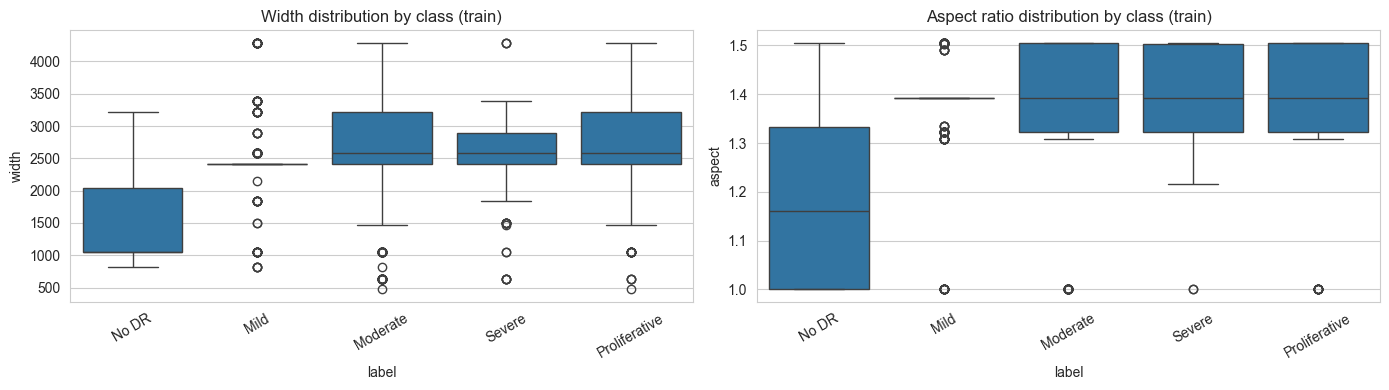

Kruskal-Wallis on width~class (train): H=1254.415  p=2.54e-270
Kruskal-Wallis on aspect~class (train): H=1176.936  p=1.59e-253


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_sub = sizes_df[sizes_df['split'] == 'train']
sns.boxplot(data=train_sub, x='label', y='width', ax=axes[0])
axes[0].set_title('Width distribution by class (train)')
axes[0].set_xticklabels(CLASS_NAMES, rotation=30)
sns.boxplot(data=train_sub, x='label', y='aspect', ax=axes[1])
axes[1].set_title('Aspect ratio distribution by class (train)')
axes[1].set_xticklabels(CLASS_NAMES, rotation=30)
plt.tight_layout()
plt.show()

from scipy.stats import kruskal
groups = [train_sub[train_sub['label']==k]['width'].values for k in range(5)]
h, p = kruskal(*groups)
print(f'Kruskal-Wallis on width~class (train): H={h:.3f}  p={p:.3g}')
groups = [train_sub[train_sub['label']==k]['aspect'].values for k in range(5)]
h, p = kruskal(*groups)
print(f'Kruskal-Wallis on aspect~class (train): H={h:.3f}  p={p:.3g}')


### A4. Illumination regime clustering

**Question:** can we cluster images into illumination regimes (well-lit, uneven,
dim) and do those regimes correlate with class?

Method: compute radial intensity profile (FOV centroid to edge) per image,
cluster with k-means (k=3).


In [9]:
# --- A4: Illumination regime clustering ---
RADIAL_CACHE = CACHE_DIR / 'aptos_radial.npz'
N_BINS = 20

if RADIAL_CACHE.exists():
    d = np.load(RADIAL_CACHE, allow_pickle=True)
    radial_codes = d['codes'].tolist()
    radial_feats = d['feats']
    radial_labels = d['labels']
    radial_split = d['split']
else:
    codes_all, feats_all, labels_all, split_all = [], [], [], []
    for split_name, labels, img_dir in [
        ('train', train_labels, TRAIN_IMG_DIR),
        ('test', test_labels, TEST_IMG_DIR),
    ]:
        for code, lbl in tqdm(labels.items(), desc=f'radial {split_name}'):
            img = load_rgb(code, img_dir)
            if img is None:
                continue
            prof = quality_metrics.radial_intensity_profile(img, n_bins=N_BINS)
            codes_all.append(code); feats_all.append(prof)
            labels_all.append(lbl); split_all.append(split_name)
    radial_codes = codes_all
    radial_feats = np.stack(feats_all).astype(np.float32)
    radial_labels = np.array(labels_all)
    radial_split = np.array(split_all)
    np.savez(RADIAL_CACHE, codes=np.array(radial_codes), feats=radial_feats,
             labels=radial_labels, split=radial_split)
print(f'Radial profiles: {radial_feats.shape}')


radial train:   0%|          | 0/3112 [00:00<?, ?it/s]

radial test:   0%|          | 0/550 [00:00<?, ?it/s]

Radial profiles: (3662, 20)


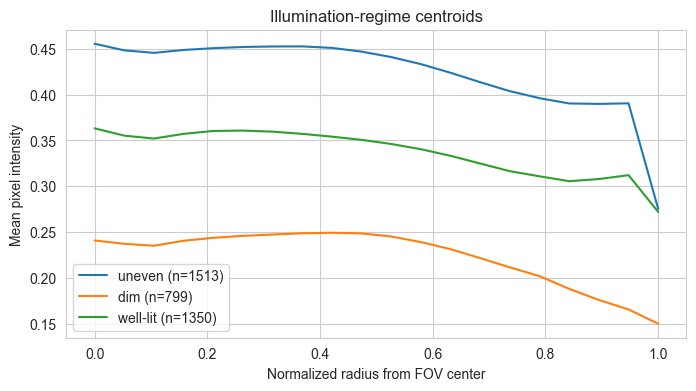

regime,dim,uneven,well-lit
label,,,
Mild,0.156,0.236,0.608
Moderate,0.203,0.331,0.466
No DR,0.226,0.527,0.247
Proliferative,0.259,0.247,0.494
Severe,0.323,0.238,0.439


Saved: C:\Projects\dr-nrt\results\eda_cache\illumination_regime.csv


In [10]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=SEED, n_init=10)
regimes = km.fit_predict(radial_feats)

# Relabel clusters: 0=dim, 1=well-lit, 2=uneven (by mean intensity and std)
regime_df = pd.DataFrame({
    'code': radial_codes, 'regime_raw': regimes, 'label': radial_labels,
    'split': radial_split,
    'mean_int': radial_feats.mean(axis=1),
    'radial_std': radial_feats.std(axis=1),
})

order = regime_df.groupby('regime_raw')['mean_int'].mean().sort_values().index
name_map = {int(order[0]): 'dim', int(order[1]): 'well-lit', int(order[2]): 'uneven'}
regime_df['regime'] = regime_df['regime_raw'].map(name_map)

# Plot cluster centroids
fig, ax = plt.subplots(figsize=(8, 4))
r = np.linspace(0, 1, N_BINS)
for k in range(3):
    ax.plot(r, km.cluster_centers_[k], label=f'{name_map[k]} (n={(regimes==k).sum()})')
ax.set_xlabel('Normalized radius from FOV center')
ax.set_ylabel('Mean pixel intensity')
ax.set_title('Illumination-regime centroids')
ax.legend()
plt.show()

# Regime × class crosstab (train only)
ct = pd.crosstab(
    regime_df[regime_df['split']=='train']['label'].map(dict(enumerate(CLASS_NAMES))),
    regime_df[regime_df['split']=='train']['regime'],
    normalize='index'
).round(3)
display(ct)

# Save regime map — used by Task 4 stratified error analysis
regime_df[['code', 'split', 'label', 'regime']].to_csv(
    CACHE_DIR / 'illumination_regime.csv', index=False,
)
print(f"Saved: {CACHE_DIR/'illumination_regime.csv'}")


### A5. Image quality × class crosstab

**Question:** is class imbalance confounded with image-quality imbalance? If
poor-quality images are overrepresented in a minority class, the model may be
learning *quality* rather than *pathology*.


In [11]:
# --- A5: Quality metrics per image ---
QUAL_CACHE = CACHE_DIR / 'aptos_quality.csv'

if QUAL_CACHE.exists():
    qual_df = pd.read_csv(QUAL_CACHE)
else:
    rows = []
    for split_name, labels, img_dir in [
        ('train', train_labels, TRAIN_IMG_DIR),
        ('test', test_labels, TEST_IMG_DIR),
    ]:
        for code, lbl in tqdm(labels.items(), desc=f'quality {split_name}'):
            img = load_rgb(code, img_dir)
            if img is None:
                continue
            m = quality_metrics.compute_all(img)
            m.update({'code': code, 'split': split_name, 'label': lbl})
            rows.append(m)
    qual_df = pd.DataFrame(rows)
    qual_df.to_csv(QUAL_CACHE, index=False)
print(qual_df.shape)


quality train:   0%|          | 0/3112 [00:00<?, ?it/s]

quality test:   0%|          | 0/550 [00:00<?, ?it/s]

(3662, 9)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33840\3316764894.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=30)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33840\3316764894.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=30)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33840\3316764894.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=30)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33840\3316764894.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=30)


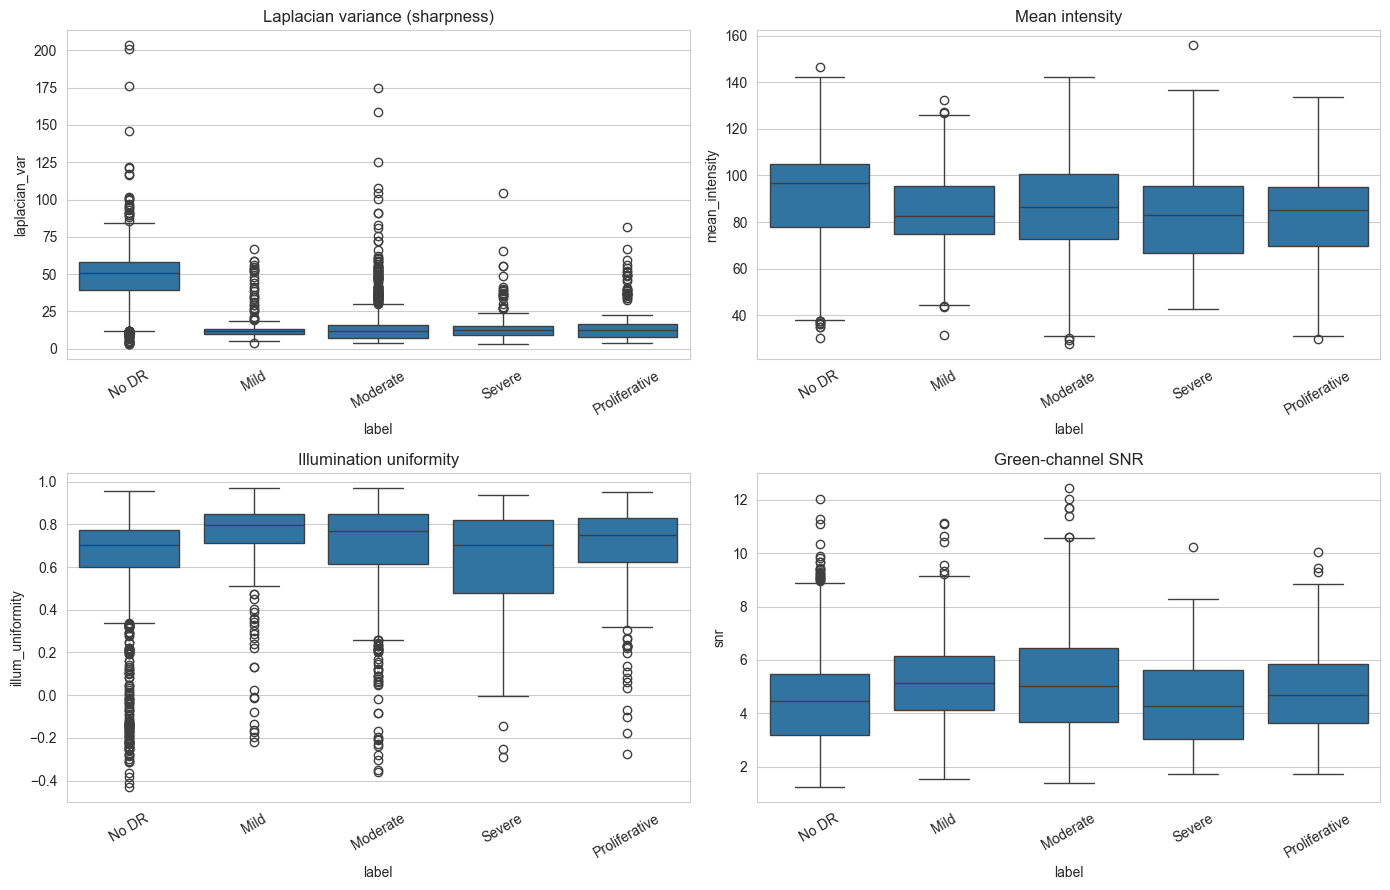

Class-effect on quality metrics (Kruskal-Wallis):
  laplacian_var        H=1413.60  p=7.77e-305  **
  mean_intensity       H=  99.71  p=1.13e-20  **
  illum_uniformity     H= 162.89  p=3.52e-34  **
  snr                  H= 106.42  p=4.23e-22  **


In [12]:
train_q = qual_df[qual_df['split']=='train']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics_to_plot = [
    ('laplacian_var', 'Laplacian variance (sharpness)'),
    ('mean_intensity', 'Mean intensity'),
    ('illum_uniformity', 'Illumination uniformity'),
    ('snr', 'Green-channel SNR'),
]
for ax, (col, title) in zip(axes.flat, metrics_to_plot):
    sns.boxplot(data=train_q, x='label', y=col, ax=ax)
    ax.set_xticklabels(CLASS_NAMES, rotation=30)
    ax.set_title(title)
plt.tight_layout()
plt.show()

# Statistical test: Kruskal-Wallis on each metric across classes
from scipy.stats import kruskal
print('Class-effect on quality metrics (Kruskal-Wallis):')
for col, _ in metrics_to_plot:
    groups = [train_q[train_q['label']==k][col].values for k in range(5)]
    h, p = kruskal(*groups)
    flag = '  **' if p < 0.05 else ''
    print(f'  {col:<20s} H={h:>7.2f}  p={p:.3g}{flag}')


In [13]:
# Quality-bin × class crosstab: do low-quality images concentrate in any class?
train_q = qual_df[qual_df['split']=='train'].copy()
train_q['blur_q'] = pd.qcut(train_q['laplacian_var'], 4,
                             labels=['q1_blurry','q2','q3','q4_sharp'])
ct = pd.crosstab(
    train_q['label'].map(dict(enumerate(CLASS_NAMES))),
    train_q['blur_q'],
    normalize='index'
).round(3)
display(ct.style.background_gradient(cmap='RdYlGn', axis=None))


blur_q,q1_blurry,q2,q3,q4_sharp
label,,,,
Mild,0.506000,0.379000,0.086000,0.029000
Moderate,0.453000,0.314000,0.192000,0.040000
No DR,0.039000,0.158000,0.331000,0.473000
Proliferative,0.434000,0.339000,0.203000,0.024000
Severe,0.396000,0.396000,0.183000,0.024000


### A6. Patient-level leakage — disclaimer

APTOS publishes a single `id_code` per image with **no patient identifier**.
We therefore cannot verify that both eyes of the same patient are in the same
split. We treat this as a documented limitation of the benchmark, not a bug in
our pipeline.

For **EyePACS** the code format is `{patient_id}_{eye}` — patient-level leakage
*can* be audited and will be in Section C.


---

## Section B — Preprocessing pipeline ablation

**Key question:** does each step of the Ben-Graham preprocessing earn its
place? We isolate the contribution of each component with a linear probe on
frozen ImageNet features.


### B1. Linear-probe ablation across preprocessing variants

For each preprocessing variant, feed images through frozen ImageNet ResNet-50,
train a logistic regression on top, evaluate QWK on the APTOS val split
(stratified 15% of train, same split as `build_datasets`).


In [14]:
# --- B1: Preprocessing variants ---
def preproc_raw(img, size=IMAGE_SIZE):
    h, w = img.shape[:2]
    s = min(h, w)
    y0 = (h - s) // 2; x0 = (w - s) // 2
    img = img[y0:y0+s, x0:x0+s]
    return cv2.resize(img, (size, size))

def preproc_clahe_green(img, size=IMAGE_SIZE):
    img = preproc_raw(img, size)
    g = img[..., 1]
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    img[..., 1] = clahe.apply(g)
    return img

def preproc_bengraham_nosubtract(img, size=IMAGE_SIZE):
    # crop to FOV then resize (no gaussian subtraction)
    mask = fundus_cv.retinal_fov_mask(img)
    ys, xs = np.where(mask)
    if ys.size:
        y0, y1 = ys.min(), ys.max(); x0, x1 = xs.min(), xs.max()
        img = img[y0:y1+1, x0:x1+1]
    return cv2.resize(img, (size, size))

def preproc_bengraham(img, size=IMAGE_SIZE, sigma_div=30):
    img = preproc_bengraham_nosubtract(img, size)
    g = cv2.GaussianBlur(img, (0,0), sigmaX=size/sigma_div)
    return cv2.addWeighted(img, 4, g, -4, 128)

VARIANTS = {
    'raw':             preproc_raw,
    'clahe_green':     preproc_clahe_green,
    'bg_nosubtract':   preproc_bengraham_nosubtract,
    'bg_sigma10':      lambda x: preproc_bengraham(x, sigma_div=10),
    'bg_sigma20':      lambda x: preproc_bengraham(x, sigma_div=20),
    'bg_sigma30':      lambda x: preproc_bengraham(x, sigma_div=30),
    'bg_sigma50':      lambda x: preproc_bengraham(x, sigma_div=50),
}
list(VARIANTS)


['raw',
 'clahe_green',
 'bg_nosubtract',
 'bg_sigma10',
 'bg_sigma20',
 'bg_sigma30',
 'bg_sigma50']

In [15]:
# Stratified 85/15 split of train (matches build_datasets seed)
from sklearn.model_selection import train_test_split

all_codes = list(train_labels.keys())
all_y = [train_labels[c] for c in all_codes]
tr_codes, va_codes, tr_y, va_y = train_test_split(
    all_codes, all_y, test_size=0.15, stratify=all_y, random_state=42,
)
print(f'Train split: {len(tr_codes)}   Val split: {len(va_codes)}')


Train split: 2645   Val split: 467


In [18]:
import importlib
from src.analysis import eda_utils
importlib.reload(eda_utils)

<module 'src.analysis.eda_utils' from 'C:\\Projects\\dr-nrt\\src\\analysis\\eda_utils.py'>

In [19]:
# --- B1: Run linear probe for each variant (GPU recommended) ---
import torch

PROBE_CACHE = CACHE_DIR / 'preproc_probe_results.csv'
PROBE_SUB = 1500  # train-subset size for speed

if PROBE_CACHE.exists():
    probe_df = pd.read_csv(PROBE_CACHE)
else:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model, preproc_imagenet = eda_utils.load_imagenet_resnet50(device=device)

    # Subsample train for speed
    tr_sub_idx = rng.choice(len(tr_codes), size=min(PROBE_SUB, len(tr_codes)),
                             replace=False)
    tr_sub = [tr_codes[i] for i in tr_sub_idx]
    tr_sub_y = np.array([tr_y[i] for i in tr_sub_idx])
    va_y_np = np.array(va_y)

    rows = []
    for name, fn in VARIANTS.items():
        def gen(codes):
            for c in codes:
                img = load_rgb(c, TRAIN_IMG_DIR)
                if img is None:
                    yield None; continue
                yield fn(img)

        def extract(codes):
            imgs = [x for x in gen(codes) if x is not None]
            return eda_utils.extract_features(imgs, model, preproc_imagenet,
                                               device=device)

        print(f'→ {name}: extract features...')
        Ftr = extract(tr_sub); Fva = extract(va_codes)
        m = eda_utils.linear_probe_qwk(Ftr, tr_sub_y, Fva, va_y_np, C=1.0)
        m['variant'] = name; rows.append(m)
        print(f'   QWK={m["qwk"]:.4f}  Macro F1={m["macro_f1"]:.4f}')

    probe_df = pd.DataFrame(rows)[['variant','qwk','macro_f1','accuracy']]
    probe_df.to_csv(PROBE_CACHE, index=False)

display(probe_df.sort_values('qwk', ascending=False).style.format(precision=4)
        .background_gradient(cmap='Greens', subset=['qwk','macro_f1','accuracy']))


→ raw: extract features...
   QWK=0.8274  Macro F1=0.6143
→ clahe_green: extract features...
   QWK=0.7793  Macro F1=0.5522
→ bg_nosubtract: extract features...
   QWK=0.7894  Macro F1=0.5843
→ bg_sigma10: extract features...
   QWK=0.8230  Macro F1=0.5907
→ bg_sigma20: extract features...
   QWK=0.8068  Macro F1=0.5827
→ bg_sigma30: extract features...
   QWK=0.8143  Macro F1=0.6144
→ bg_sigma50: extract features...
   QWK=0.7817  Macro F1=0.5692


,variant,qwk,macro_f1,accuracy
0,raw,0.8274,0.6143,0.7752
3,bg_sigma10,0.8230,0.5907,0.7623
5,bg_sigma30,0.8143,0.6144,0.7623
4,bg_sigma20,0.8068,0.5827,0.7452
2,bg_nosubtract,0.7894,0.5843,0.7516
6,bg_sigma50,0.7817,0.5692,0.7302
1,clahe_green,0.7793,0.5522,0.7302


### B2. Augmentation sanity check — does pathology survive?

For 20 APTOS images, apply each Level-2 augmentation and measure what
fraction of *microaneurysm candidates* survive. Justifies dropping destructive
augmentations (`ElasticTransform`, `CoarseDropout`, `GridDistortion`) from the
offline oversampling pipeline.


In [20]:
# --- B2: Augmentation sanity check ---
import albumentations as A

augs = {
    'hflip': A.HorizontalFlip(p=1.0),
    'rot90': A.RandomRotate90(p=1.0),
    'shift_scale_rotate': A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15,
                                              rotate_limit=180, p=1.0, border_mode=0),
    'brightness_contrast': A.RandomBrightnessContrast(brightness_limit=0.2,
                                                      contrast_limit=0.2, p=1.0),
    'hue_sat_val': A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20,
                                         val_shift_limit=20, p=1.0),
    'clahe': A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=1.0),
    'gauss_blur': A.GaussianBlur(blur_limit=(3,5), p=1.0),
    'elastic (destructive)': A.ElasticTransform(alpha=120, sigma=6, p=1.0,
                                                 border_mode=0),
    'coarse_dropout (destructive)': A.CoarseDropout(max_holes=8, max_height=32,
                                                      max_width=32, fill_value=0,
                                                      p=1.0),
    'grid_distort (destructive)': A.GridDistortion(num_steps=5, distort_limit=0.3,
                                                    p=1.0, border_mode=0),
}

# Pick 20 grade-1/2/3 (pathology-bearing) images
codes_path = [c for c in train_labels if train_labels[c] in (1, 2, 3)]
sample_codes = rng.choice(codes_path, size=20, replace=False).tolist()

rows = []
for code in tqdm(sample_codes, desc='aug audit'):
    img = load_rgb(code, TRAIN_IMG_DIR)
    if img is None:
        continue
    img = ben_graham_preprocess(img, IMAGE_SIZE)
    base_mask = fundus_cv.ma_candidates(img)
    base_count = int(base_mask.sum() > 0) and int(
        cv2.connectedComponents(base_mask)[0] - 1
    )
    for aname, aug in augs.items():
        out = aug(image=img)['image']
        m = fundus_cv.ma_candidates(out)
        aug_count = int(m.sum() > 0) and int(cv2.connectedComponents(m)[0] - 1)
        rows.append({
            'code': code, 'aug': aname,
            'base_ma': base_count, 'aug_ma': aug_count,
            'retention': aug_count / max(base_count, 1),
        })

aug_df = pd.DataFrame(rows)
survival = aug_df.groupby('aug')['retention'].agg(['mean','median','std']).round(3)
survival = survival.sort_values('median', ascending=False)
display(survival)


c:\Projects\dr-nrt\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33840\4047048991.py:17: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  'coarse_dropout (destructive)': A.CoarseDropout(max_holes=8, max_height=32,


aug audit:   0%|          | 0/20 [00:00<?, ?it/s]

,mean,median,std
aug,,,
clahe,3.106,2.957,0.921
elastic (destructive),1.116,1.064,0.193
coarse_dropout (destructive),1.059,1.029,0.106
grid_distort (destructive),1.056,1.012,0.166
rot90,1.000,1.000,0.000
hflip,1.000,1.000,0.000
brightness_contrast,0.946,0.919,0.169
hue_sat_val,0.980,0.904,0.255
shift_scale_rotate,0.929,0.871,0.252


### B3. Class separability — pre vs post Ben Graham

Compute per-class mean image **before** and **after** Ben Graham preprocessing;
measure pairwise MSE between class-means. Ben Graham should **increase** or
**maintain** class separability in pixel space; if it reduces it, that's a red
flag.


class 0:   0%|          | 0/80 [00:00<?, ?it/s]

class 1:   0%|          | 0/80 [00:00<?, ?it/s]

class 2:   0%|          | 0/80 [00:00<?, ?it/s]

class 3:   0%|          | 0/80 [00:00<?, ?it/s]

class 4:   0%|          | 0/80 [00:00<?, ?it/s]

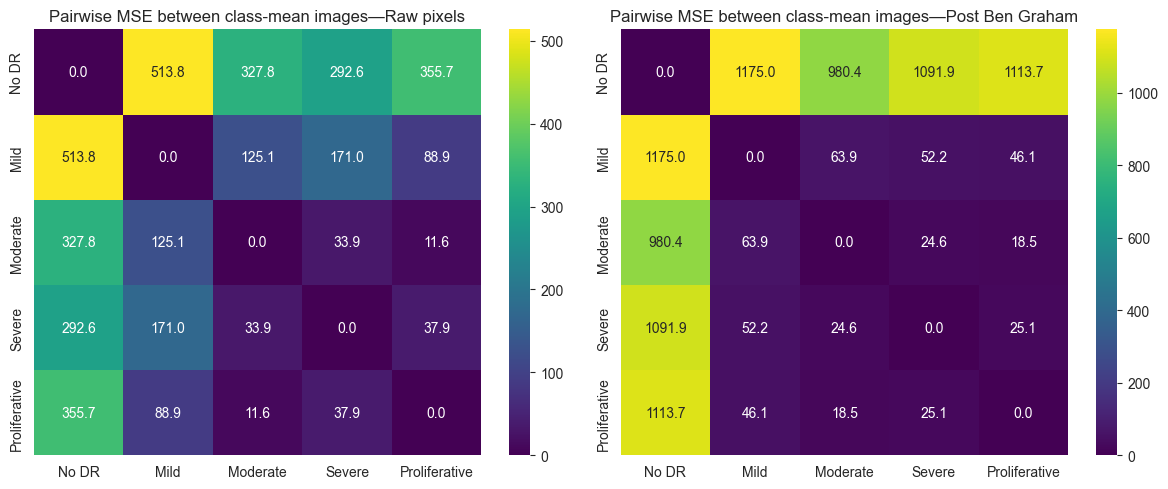

Off-diagonal mean MSE (higher = more separable):
  Raw       : 195.8
  Post B-G  : 459.1


In [21]:
# --- B3: Per-class mean-image separability ---
means_pre = {k: [] for k in range(5)}
means_post = {k: [] for k in range(5)}
SAMPLE_PER = 80

for k in range(5):
    codes_k = [c for c in train_labels if train_labels[c] == k]
    sub = rng.choice(codes_k, size=min(SAMPLE_PER, len(codes_k)), replace=False).tolist()
    for c in tqdm(sub, desc=f'class {k}'):
        img = load_rgb(c, TRAIN_IMG_DIR)
        if img is None:
            continue
        means_pre[k].append(cv2.resize(img, (256, 256)).astype(np.float32))
        means_post[k].append(cv2.resize(
            ben_graham_preprocess(img, IMAGE_SIZE), (256, 256)
        ).astype(np.float32))

mean_pre = {k: np.stack(v).mean(axis=0) for k, v in means_pre.items()}
mean_post = {k: np.stack(v).mean(axis=0) for k, v in means_post.items()}

def pair_mse(means):
    M = np.zeros((5,5))
    for i in range(5):
        for j in range(5):
            M[i,j] = np.mean((means[i] - means[j]) ** 2)
    return M

mse_pre = pair_mse(mean_pre)
mse_post = pair_mse(mean_post)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, M, title in zip(axes, [mse_pre, mse_post], ['Raw pixels', 'Post Ben Graham']):
    sns.heatmap(M, annot=True, fmt='.1f', cmap='viridis', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f'Pairwise MSE between class-mean images—{title}')
plt.tight_layout(); plt.show()
print('Off-diagonal mean MSE (higher = more separable):')
print(f'  Raw       : {mse_pre[np.triu_indices(5,1)].mean():.1f}')
print(f'  Post B-G  : {mse_post[np.triu_indices(5,1)].mean():.1f}')


### B4. Color-space linear probe

Linear probe on Ben-Graham-preprocessed features in different color spaces,
to validate the green-channel dominance claim from `eda_aptos.ipynb`.


In [22]:
# --- B4: Color-space linear probe ---
# Uses the same train sub + val split from B1.
# Convert each preprocessed image to a target color space before sending through ResNet-50.
import torch

SPACE_CACHE = CACHE_DIR / 'colorspace_probe_results.csv'

def to_space(img, space):
    if space == 'rgb':
        return img
    if space == 'hsv':
        return cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    if space == 'lab':
        return cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    if space == 'green':
        g = img[..., 1]
        return np.stack([g, g, g], axis=-1)
    raise ValueError(space)

if SPACE_CACHE.exists():
    space_df = pd.read_csv(SPACE_CACHE)
else:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model, preproc_imagenet = eda_utils.load_imagenet_resnet50(device=device)
    tr_sub_idx = rng.choice(len(tr_codes), size=min(PROBE_SUB, len(tr_codes)),
                             replace=False)
    tr_sub = [tr_codes[i] for i in tr_sub_idx]
    tr_sub_y = np.array([tr_y[i] for i in tr_sub_idx])
    va_y_np = np.array(va_y)

    rows = []
    for space in ['rgb','hsv','lab','green']:
        def gen(codes):
            for c in codes:
                img = load_rgb(c, TRAIN_IMG_DIR)
                if img is None: yield None; continue
                yield to_space(ben_graham_preprocess(img, IMAGE_SIZE), space)

        Ftr = eda_utils.extract_features([x for x in gen(tr_sub) if x is not None],
                                          model, preproc_imagenet, device=device)
        Fva = eda_utils.extract_features([x for x in gen(va_codes) if x is not None],
                                          model, preproc_imagenet, device=device)
        m = eda_utils.linear_probe_qwk(Ftr, tr_sub_y, Fva, va_y_np)
        m['space'] = space
        rows.append(m)
        print(f'{space:<8s} QWK={m["qwk"]:.4f}')
    space_df = pd.DataFrame(rows)[['space','qwk','macro_f1','accuracy']]
    space_df.to_csv(SPACE_CACHE, index=False)

display(space_df.sort_values('qwk', ascending=False).style.format(precision=4))


rgb      QWK=0.7873
hsv      QWK=0.7384
lab      QWK=0.7785
green    QWK=0.8379


,space,qwk,macro_f1,accuracy
3,green,0.8379,0.6145,0.7837
0,rgb,0.7873,0.5807,0.7537
2,lab,0.7785,0.5682,0.7302
1,hsv,0.7384,0.5532,0.7109


---

## Section C — Cross-dataset audit

Characterises the three datasets used in the thesis (APTOS, EyePACS, IDRiD)
along color, illumination, resolution, and label-noise axes. Provides the
thesis' §3.2 Dataset Limitations.


### C1. APTOS vs EyePACS vs IDRiD — statistical summary

Compute mean per-channel stats + quality metrics per dataset from a stratified
subsample.


In [23]:
# --- C1: Cross-dataset summary ---
EYEPACS_DIR = ROOT / 'data' / 'eyepacs_processed'
EYEPACS_CSV = ROOT / 'data' / 'eyepacs_labels.csv'

dataset_sources = [
    ('APTOS-train', train_labels, TRAIN_IMG_DIR),
]
if EYEPACS_CSV.exists() and EYEPACS_DIR.exists():
    dataset_sources.append(('EyePACS', load_labels(EYEPACS_CSV), EYEPACS_DIR))
if IDRID_CSV.exists() and IDRID_PROCESSED_DIR.exists():
    dataset_sources.append(('IDRiD', load_labels(IDRID_CSV), IDRID_PROCESSED_DIR))

CROSS_CACHE = CACHE_DIR / 'crossdataset_summary.csv'
N_PER_CLASS = 40

if CROSS_CACHE.exists():
    cross_df = pd.read_csv(CROSS_CACHE)
else:
    rows = []
    for dname, labels, img_dir in dataset_sources:
        codes = stratified_sample(labels, N_PER_CLASS, rng)
        for code in tqdm(codes, desc=dname):
            img = load_rgb(code, img_dir)
            if img is None:
                continue
            q = quality_metrics.compute_all(img)
            q['dataset'] = dname; q['label'] = labels[code]
            q['r_mean'] = float(img[..., 0].mean())
            q['g_mean'] = float(img[..., 1].mean())
            q['b_mean'] = float(img[..., 2].mean())
            rows.append(q)
    cross_df = pd.DataFrame(rows)
    cross_df.to_csv(CROSS_CACHE, index=False)

summary = cross_df.groupby('dataset').agg(
    n=('label', 'count'),
    laplacian_var=('laplacian_var', 'mean'),
    mean_intensity=('mean_intensity', 'mean'),
    illum_uniformity=('illum_uniformity', 'mean'),
    snr=('snr', 'mean'),
    r=('r_mean', 'mean'), g=('g_mean', 'mean'), b=('b_mean', 'mean'),
).round(2)
display(summary)


APTOS-train:   0%|          | 0/200 [00:00<?, ?it/s]

EyePACS:   0%|          | 0/200 [00:00<?, ?it/s]

IDRiD:   0%|          | 0/80 [00:00<?, ?it/s]

,n,laplacian_var,mean_intensity,illum_uniformity,snr,r,g,b
dataset,,,,,,,,
APTOS-train,200,21.80,82.78,0.66,4.60,103.75,55.06,18.58
EyePACS,200,913.30,133.88,0.64,3.67,128.69,127.80,127.70
IDRiD,80,2313.96,129.07,0.72,3.68,129.53,127.84,127.94


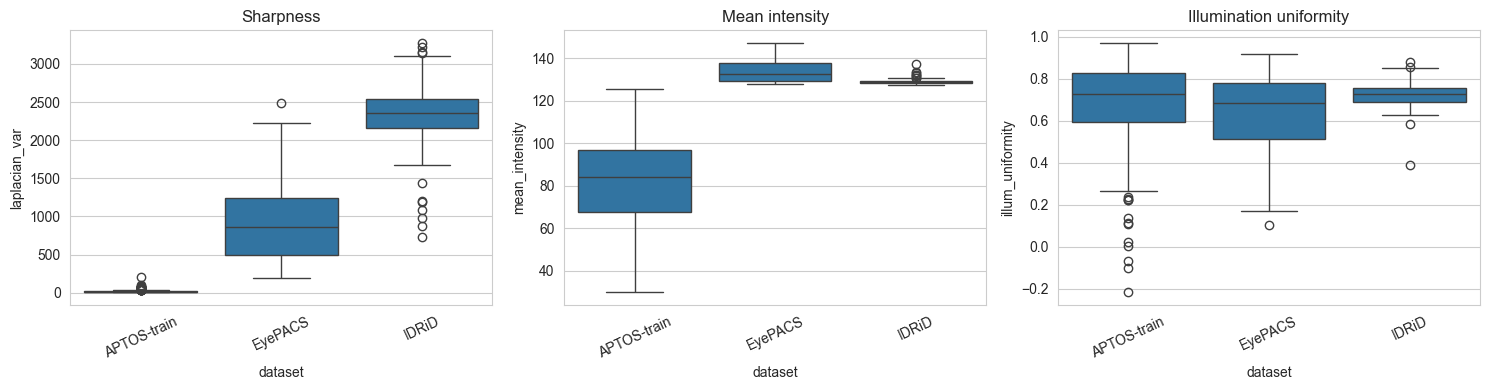

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=cross_df, x='dataset', y='laplacian_var', ax=axes[0]); axes[0].set_title('Sharpness')
sns.boxplot(data=cross_df, x='dataset', y='mean_intensity', ax=axes[1]); axes[1].set_title('Mean intensity')
sns.boxplot(data=cross_df, x='dataset', y='illum_uniformity', ax=axes[2]); axes[2].set_title('Illumination uniformity')
for ax in axes:
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()


### C2. EyePACS label-noise estimate (optional — requires trained model)

Predict EyePACS with an APTOS-trained exp701 checkpoint; report per-class
disagreement as a proxy for label noise in EyePACS. Cross-references Krause
et al. (2018) who found ~20% disagreement on adjudicated DR labels.

**Skip cell if you do not yet want to load checkpoints.**


In [25]:
# --- C2: EyePACS label-noise estimate ---
# This cell is gated behind checkpoint availability. Uncomment to run.
print('Skipped by default. See plan Task 4 §C2 for the procedure:')
print('  1. Load checkpoints/exp701_*.pt')
print('  2. Inference over EyePACS with TTA')
print('  3. Report per-class argmax disagreement with stored labels')


Skipped by default. See plan Task 4 §C2 for the procedure:
  1. Load checkpoints/exp701_*.pt
  2. Inference over EyePACS with TTA
  3. Report per-class argmax disagreement with stored labels


---

## Deliverables produced

- `results/eda_cache/aptos_features.npz` — ImageNet ResNet-50 features for MMD.
- `results/eda_cache/aptos_phash.npz` — pHash vectors for duplicate scan.
- `results/eda_cache/aptos_sizes.csv` — per-image resolution & aspect.
- `results/eda_cache/aptos_radial.npz` — radial-illumination features.
- `results/eda_cache/illumination_regime.csv` — per-image regime label **(feeds Task 4 stratified error analysis).**
- `results/eda_cache/aptos_quality.csv` — blur/SNR/illum per image **(feeds Task 4).**
- `results/eda_cache/preproc_probe_results.csv` — preprocessing ablation table.
- `results/eda_cache/colorspace_probe_results.csv` — color-space ablation table.
- `results/eda_cache/crossdataset_summary.csv` — APTOS vs EyePACS vs IDRiD stats.

## Thesis artifacts

- **Table (§3.2):** linear-probe QWK by preprocessing variant → justifies Ben-Graham + σ=30.
- **Table (§3.2):** color-space linear-probe → validates green-channel dominance.
- **Figure (§3.2):** illumination-regime centroids, quality-by-class boxplots.
- **Figure (§3.2):** class-mean MSE heatmap (raw vs post-BG).
- **Table (§3.2):** cross-dataset statistical summary.
- **Paragraph (§3.2):** patient-leakage disclaimer + duplicate-audit summary.
